# Loan Data Analysis & Machine Learning Analysis
**Dataset:** `Loan_Data_4_Looker.csv`

This notebook covers the data science process: Data Exploration, Data Transformation, Data Visualization, and Machine Learning (Regression, Classification, and Clustering) with proper validation techniques.

Creator: Thananop Kullapan

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, mean_squared_error, silhouette_score
import statsmodels.api as sm

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Exploration
Let's load the dataset and perform an initial inspection to understand its structure, statistical summary, and check for missing values before proceeding to transformation.

In [33]:
# Load the dataset
df = pd.read_excel('loan_data.xlsx')

# 1.1 Data Info
print("--- DataFrame Info ---")
df.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      10000 non-null  int64  
 1   loan_amnt               10000 non-null  int64  
 2   funded_amnt             10000 non-null  int64  
 3   term                    9524 non-null   object 
 4   int_rate                9524 non-null   float64
 5   installment             9524 non-null   float64
 6   emp_length              9119 non-null   object 
 7   home_ownership          9524 non-null   object 
 8   annual_inc              9524 non-null   float64
 9   loan_status             9524 non-null   object 
 10  purpose                 9524 non-null   object 
 11  addr_state              10000 non-null  object 
 12  dti                     9524 non-null   float64
 13  delinq_2yrs             9524 non-null   float64
 14  earliest_cr_line

In [34]:
# 1.2 Descriptive Statistics
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,id,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,mths_since_last_delinq,open_acc,revol_bal,total_acc,out_prncp,total_pymnt,total_rec_prncp,total_rec_int
count,1.000000e+04,10000.000000,10000.00000,9524.000000,9524.000000,9524.000000,9524.000000,9524.000000,4100.000000,9524.000000,9524.000000,9524.000000,9524.000000,9524.000000,9524.000000,9524.000000
mean,5.143648e+06,14054.807500,14052.73000,0.142779,442.626605,71655.752245,17.146927,0.238765,34.988537,11.043784,15982.998215,24.517640,10253.674229,5225.240946,3808.501311,1412.893987
std,2.827944e+06,8108.658728,8107.69323,0.044302,244.522116,45362.834495,7.591601,0.691455,21.474509,4.561028,15177.648105,10.887693,7963.300050,5499.478657,4801.501191,1489.227516
min,5.712030e+05,1000.000000,1000.00000,0.060300,30.440000,7500.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,34.140000,22.500000,11.640000
25%,2.300882e+06,8000.000000,8000.00000,0.111400,266.575000,45000.000000,11.520000,0.000000,17.000000,8.000000,7151.000000,17.000000,4273.387500,1676.312500,1027.525000,468.112500
50%,5.605038e+06,12000.000000,12000.00000,0.140900,398.510000,61000.000000,16.840000,0.000000,32.000000,10.000000,12495.000000,23.000000,8745.425000,3500.040000,2237.870000,947.000000
75%,7.435741e+06,19400.000000,19400.00000,0.172700,576.737500,86000.000000,22.590000,0.000000,49.000000,14.000000,20596.000000,31.000000,15055.437500,6736.965000,4544.470000,1777.870000
max,1.012507e+07,35000.000000,35000.00000,0.260600,1388.450000,1000000.000000,34.980000,11.000000,122.000000,39.000000,376679.000000,68.000000,34413.520000,44231.080000,35000.010000,13514.550000


In [35]:
# 1.3 Missing Values Check
print("\n--- Missing Values Count ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Missing Values Count ---
term                       476
int_rate                   476
installment                476
emp_length                 881
home_ownership             476
annual_inc                 476
loan_status                476
purpose                    476
dti                        476
delinq_2yrs                476
earliest_cr_line           476
mths_since_last_delinq    5900
open_acc                   476
revol_bal                  476
total_acc                  476
out_prncp                  476
total_pymnt                476
total_rec_prncp            476
total_rec_int              476
dtype: int64


## 2. Data Transformation
**Insights:**
We observed missing values in `emp_length` and `mths_since_last_delinq`. We will impute these and drop unnecessary identification columns. Categorical variables will be encoded, and numerical features will be scaled for distance-based ML algorithms (like SVM, kNN, and KMeans).

2.1. Data Transformation for Looker Studio

In [36]:
# 2.1.1. Drop missing values in the 'loan_status' column
df = df.dropna(subset=['loan_status']).copy()

In [37]:
# 2.1.2. Group Loan Status to create 'loan_condition' and 'is_bad' columns
good_statuses = ['Current', 'Fully Paid']

# If the status is in good_statuses, it's considered a Good Loan; otherwise, a Bad Loan
df['loan_condition'] = np.where(df['loan_status'].isin(good_statuses), 'Good Loan', 'Bad Loan')

In [38]:
# Set Bad Loan = 1 and Good Loan = 0
df['is_bad'] = np.where(df['loan_condition'] == 'Bad Loan', 1, 0)

In [39]:
# 2.1.3. Extract numeric values from the 'term' column (e.g., " 36 months" to 36, 60)
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(int)

In [40]:
# 2.1.4. Cap the 'annual_inc' column at the 99th percentile (225,000)
upper_limit = df['annual_inc'].quantile(0.99)
df['annual_inc_capped'] = df['annual_inc'].clip(upper=upper_limit)

In [41]:
# 2.1.5. Create 'int_rate_category' column based on 'int_rate'
def categorize_rate(rate):
    if rate < 0.10:
        return 'Low (<10%)'
    elif rate <= 0.15:
        return 'Medium (10-15%)'
    else:
        return 'High (>15%)'

df['int_rate_category'] = df['int_rate'].apply(categorize_rate)

In [42]:
# 2.1.6. Format the date in 'earliest_cr_line' to YYYY-MM-DD HH:MM:SS
# Handle mixed date formats and day-first scenarios (dayfirst=True)
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], dayfirst=True, format='mixed')
df['earliest_cr_line'] = df['earliest_cr_line'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [43]:
# 2.1.7. Save the result as a new CSV file for use in Looker
df.to_csv('Loan_Data_4_Looker.csv', index=False)

print("Data transformation successful! Data shape:", df.shape)

Data transformation successful! Data shape: (9524, 28)


2.2. Data Transformation for ML

In [44]:
# Make a copy for ML processing
df_clean = df.copy()

# 2.2.1 Handle Missing Values
# Fill missing employment length with mode
df_clean['emp_length'] = df_clean['emp_length'].fillna(df_clean['emp_length'].mode()[0])

In [45]:
# Fill missing months since last delinquency with an outlier value (e.g., 999) or drop if not needed
df_clean['mths_since_last_delinq'] = df_clean['mths_since_last_delinq'].fillna(999)

In [46]:
# 2.2.2 Drop non-predictive or redundant columns
cols_to_drop = ['id', 'earliest_cr_line', 'loan_status']
df_clean.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [47]:
# 2.2.3 Encoding Categorical Variables
categorical_cols = df_clean.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

In [48]:
# 2.2.4 Feature Scaling (Crucial for SVM, kNN, Clustering)
scaler = StandardScaler()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
# We don't scale the target variable 'is_bad'
num_cols.remove('is_bad')

df_scaled = df_clean.copy()
df_scaled[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [49]:
print("Data Transformation Completed. Shape:", df_scaled.shape)

Data Transformation Completed. Shape: (9524, 25)


## 3. Data Visualization
**Insights:**
Exploring the distribution of loan amounts, the balance of loan conditions, the relationship between annual income and loan amount, and the trend of interest rates across different terms.

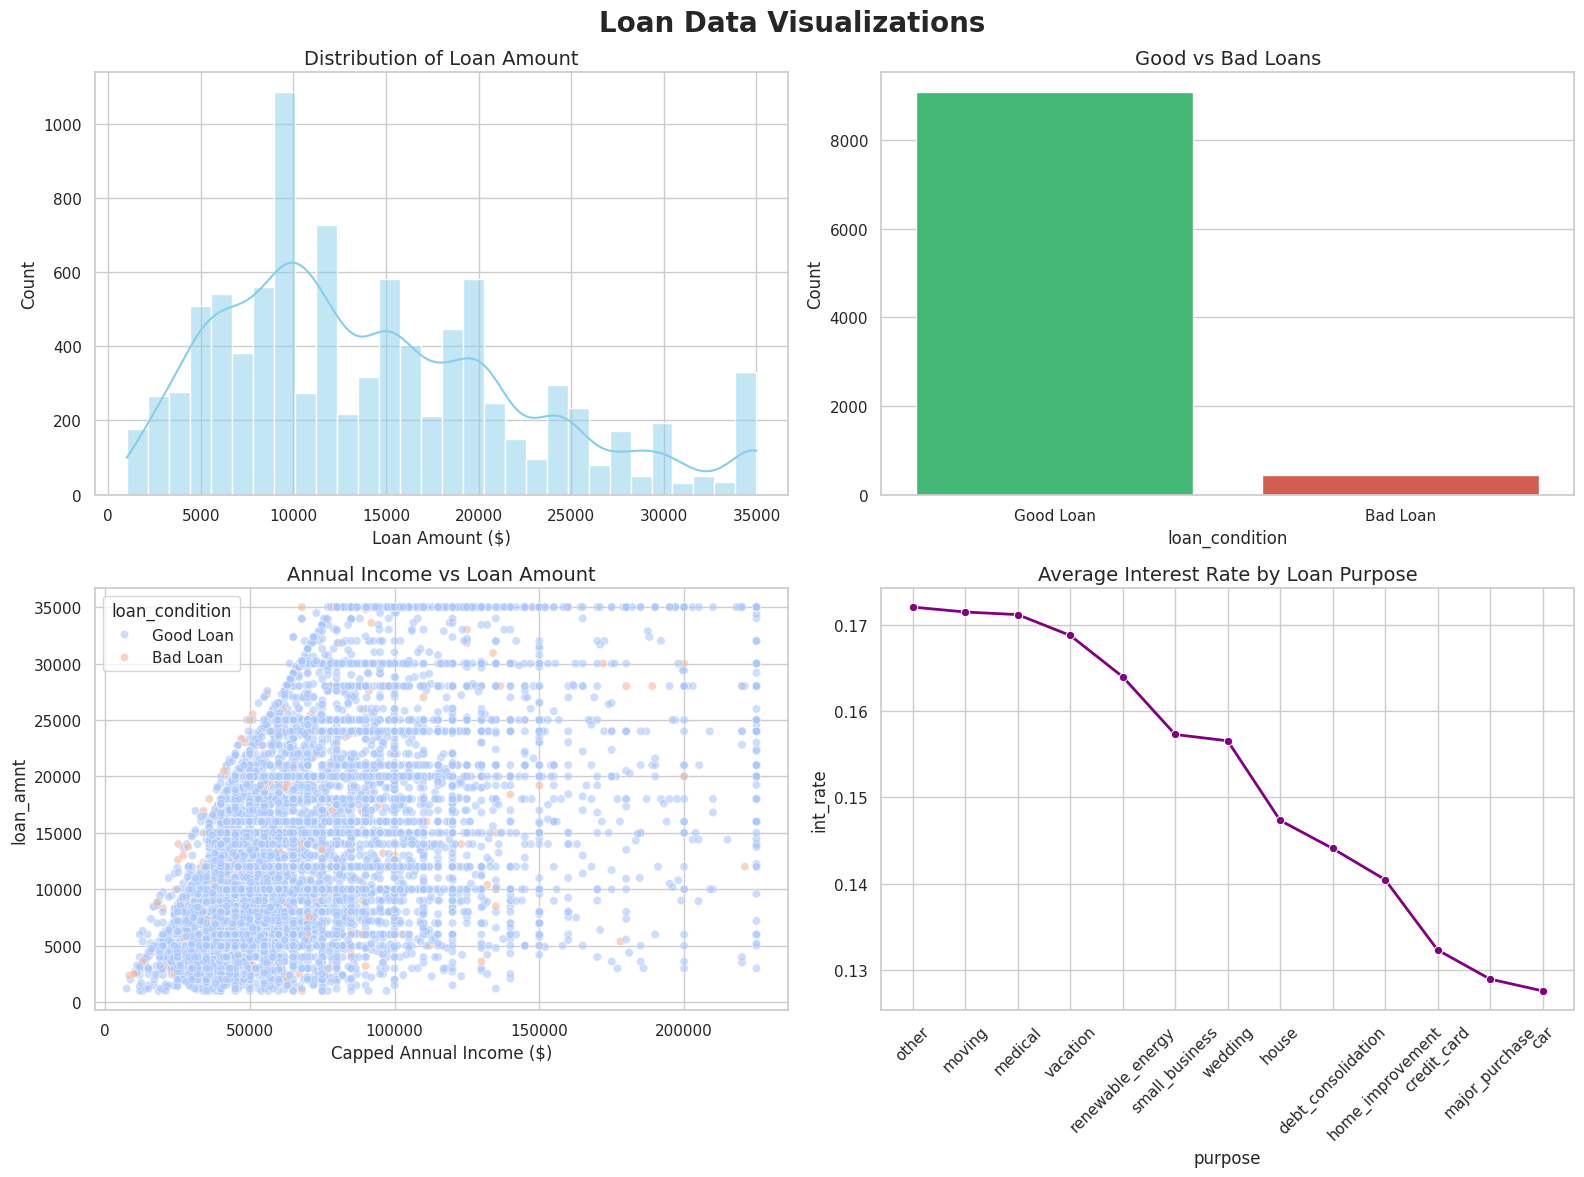

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Loan Data Visualizations', fontsize=20, fontweight='bold')

# 1. Histogram: Distribution of Loan Amount
sns.histplot(df['loan_amnt'], bins=30, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Loan Amount', fontsize=14)
axes[0, 0].set_xlabel('Loan Amount ($)')

# 2. Bar Chart: Loan Condition Count
sns.countplot(data=df, x='loan_condition', palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1])
axes[0, 1].set_title('Good vs Bad Loans', fontsize=14)
axes[0, 1].set_ylabel('Count')

# 3. Scatter Plot: Annual Income vs Loan Amount (Capped at 99th percentile for better view)
sns.scatterplot(data=df, x='annual_inc_capped', y='loan_amnt', hue='loan_condition',
                palette='coolwarm', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Annual Income vs Loan Amount', fontsize=14)
axes[1, 0].set_xlabel('Capped Annual Income ($)')

# 4. Line Chart: Average Interest Rate by Purpose
avg_int_rate = df.groupby('purpose')['int_rate'].mean().sort_values(ascending=False).reset_index()
sns.lineplot(data=avg_int_rate, x='purpose', y='int_rate', marker='o', color='purple', linewidth=2, ax=axes[1, 1])
axes[1, 1].set_title('Average Interest Rate by Loan Purpose', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Machine Learning: Regression & Outlier Detection
**Insights:**
We will predict the `int_rate` based on features like `loan_amnt`, `annual_inc`, and `term_months`. Before finalizing the regression, we use **Cook's Distance** to identify and visualize highly influential outliers that might skew our model.

In [51]:
# Prepare data for Regression
X_reg = df_scaled[['loan_amnt', 'annual_inc_capped', 'term_months', 'dti']]
y_reg = df['int_rate'] # Use unscaled target for interpretability

# Add constant for statsmodels
X_reg_sm = sm.add_constant(X_reg)

# Fit OLS model
ols_model = sm.OLS(y_reg, X_reg_sm).fit()

# Calculate Cook's Distance
influence = ols_model.get_influence()
cooks_d, pvals = influence.cooks_distance

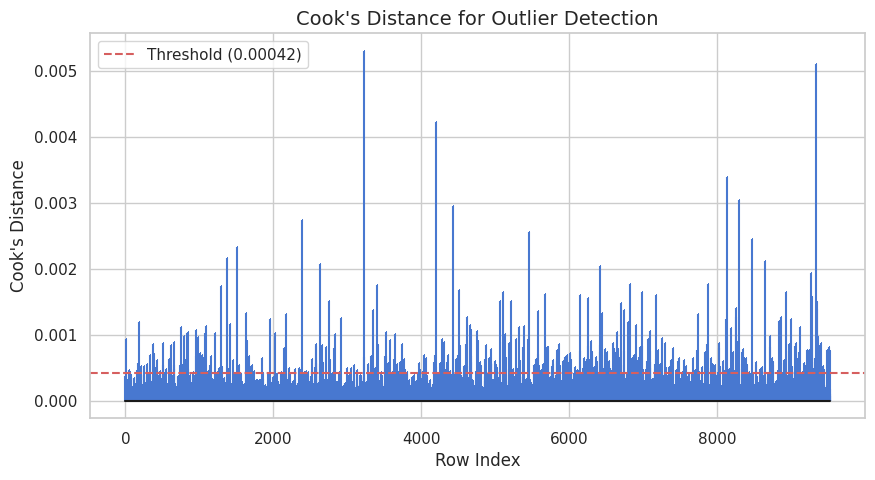

In [52]:
# Visualize Cook's Distance
plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt="k-")
plt.title("Cook's Distance for Outlier Detection", fontsize=14)
plt.xlabel('Row Index')
plt.ylabel("Cook's Distance")
# Threshold line (commonly 4/n)
threshold = 4 / len(X_reg)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.5f})')
plt.legend()
plt.show()

In [53]:
# Filter out rows where Cook's Distance exceeds the threshold
non_outlier_mask = cooks_d < threshold
X_reg_clean = X_reg[non_outlier_mask]
y_reg_clean = y_reg[non_outlier_mask]

print(f"Original records: {len(X_reg)}")
print(f"Records after removing outliers: {len(X_reg_clean)}")
print(f"Outliers removed: {len(X_reg) - len(X_reg_clean)}\n")

Original records: 9524
Records after removing outliers: 9049
Outliers removed: 475



In [54]:
# --- Linear Regression Evaluation ---
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_clean, y_reg_clean, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)

print(f"Regression RMSE (Outliers Removed): {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")

Regression RMSE (Outliers Removed): 0.0347


## 5. Machine Learning: Classification
**Insights:**
Objective: Predict `is_bad` (Bad Loan). We apply Logistic Regression, Support Vector Machines (SVM with RBF kernel), and k-Nearest Neighbors (kNN). We use **k-Fold Cross Validation** to ensure model robustness.

*(Note: To save computation time in this demonstration, SVM is run on a subset or with specific parameters, but k-Fold is applied to LogReg).*

In [55]:
# Prepare Data for Classification
X_clf = df_scaled.drop(['is_bad', 'loan_condition'], axis=1)
y_clf = df_scaled['is_bad']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [56]:
# 1. Logistic Regression with k-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(log_reg, X_train_c, y_train_c, cv=kf, scoring='accuracy')

print("--- Logistic Regression ---")
print(f"K-Fold CV Accuracy Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f}\n")

log_reg.fit(X_train_c, y_train_c)
print(classification_report(y_test_c, log_reg.predict(X_test_c)))

--- Logistic Regression ---
K-Fold CV Accuracy Scores: [0.9691601  0.97047244 0.97506562 0.97244094 0.96979645]
Average CV Accuracy: 0.9714

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1815
           1       1.00      0.41      0.58        90

    accuracy                           0.97      1905
   macro avg       0.99      0.71      0.78      1905
weighted avg       0.97      0.97      0.97      1905



In [57]:
# 2. k-Nearest Neighbors (kNN)
print("--- k-Nearest Neighbors (k=5) ---")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c, y_train_c)
print(classification_report(y_test_c, knn.predict(X_test_c)))

--- k-Nearest Neighbors (k=5) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1815
           1       0.33      0.01      0.02        90

    accuracy                           0.95      1905
   macro avg       0.64      0.51      0.50      1905
weighted avg       0.92      0.95      0.93      1905



In [58]:
# 3. Support Vector Machine (RBF Kernel)
print("--- Support Vector Machine (RBF) ---")
svm_model = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_model.fit(X_train_c, y_train_c)
print(classification_report(y_test_c, svm_model.predict(X_test_c)))

--- Support Vector Machine (RBF) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1815
           1       1.00      0.30      0.46        90

    accuracy                           0.97      1905
   macro avg       0.98      0.65      0.72      1905
weighted avg       0.97      0.97      0.96      1905

